# Supervised ViT fine-tune ablation: CNN + ViT hybrid

Классификация 26 видов. Абляция от текущего ViT LF-PE baseline с SSL checkpoint `vit_lfpe_ssl_pretrain_best.pt`.

**Чекпоинт:** `checkpoints/vit_lfpe_bat_ablation_10_cnn_hybrid_best.pt`

**Важно:** запускать как отдельный эксперимент, не resume старого baseline task.


In [1]:
from pathlib import Path
import os
import sys
import warnings
import math

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import soundfile as sf
from scipy import signal
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
)
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from IPython.display import display
from tqdm.auto import tqdm

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)


# ClearML и пути

Пути к данным и чекпоинтам, загрузка `.env`, device (`mps`), инициализация ClearML Task и OutputModel.


In [2]:
PROJECT_DIR = Path("/Users/katterns/ITMO/Practice")
sys.path.insert(0, str(PROJECT_DIR))

DATA_DIR = PROJECT_DIR / "cleaned_subset_200"
METADATA_PATH = DATA_DIR / "audio_metadata_cleaned.csv"
CHECKPOINT_DIR = PROJECT_DIR / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
SSL_PRETRAIN_CKPT = CHECKPOINT_DIR / "vit_lfpe_ssl_pretrain_best.pt"
BEST_CKPT = CHECKPOINT_DIR / "vit_lfpe_bat_ablation_10_cnn_hybrid_best.pt"
TRAIN_LOG_TXT = CHECKPOINT_DIR / "vit_lfpe_bat_ablation_10_cnn_hybrid_log.txt"

import logging
from dotenv import load_dotenv

load_dotenv(PROJECT_DIR / ".env", override=False)

CLEARML_QUIET = os.environ.get("CLEARML_QUIET", "1").strip().lower() in ("1", "true", "yes")
CLEARML_UPLOAD_EACH_BEST = os.environ.get("CLEARML_UPLOAD_EACH_BEST", "0").strip().lower() in (
    "1", "true", "yes",
)


def setup_clearml_console(quiet: bool = True) -> None:
    if not quiet:
        return
    for name in ("clearml", "clearml.storage", "clearml.model", "clearml.Task"):
        logging.getLogger(name).setLevel(logging.WARNING)
    try:
        from clearml.storage.callbacks import ProgressReport

        def _no_tqdm(self):
            self._tqdm_init = True
            return None

        ProgressReport._get_tqdm = _no_tqdm
    except Exception:
        pass


setup_clearml_console(CLEARML_QUIET)

from clearml import OutputModel, Task

device = torch.device("mps")

# --- ClearML ---
RESUME_FROM_BEST = False
CLEARML_CONTINUE_LAST = False
CLEARML_TASK_ID = None
CLEARML_PROJECT = "my project"
CLEARML_TASK_NAME = "vit_lfpe_bat_ablation_10_cnn_hybrid_2sec"

clearml_output_uri = os.environ.get("CLEARML_OUTPUT_URI", True)
if isinstance(clearml_output_uri, str) and clearml_output_uri.lower() in ("false", "0", "no", "none"):
    clearml_output_uri = False

_task_init_kw = dict(
    project_name=CLEARML_PROJECT,
    task_name=CLEARML_TASK_NAME,
    output_uri=clearml_output_uri,
    auto_resource_monitoring=False,
)
if CLEARML_TASK_ID:
    _task_init_kw["continue_last_task"] = CLEARML_TASK_ID
    _task_init_kw["reuse_last_task_id"] = CLEARML_TASK_ID
elif CLEARML_CONTINUE_LAST and RESUME_FROM_BEST:
    _task_init_kw["continue_last_task"] = 0
    _task_init_kw["reuse_last_task_id"] = True
else:
    _task_init_kw["reuse_last_task_id"] = False

clearml_task = Task.init(**_task_init_kw)
output_dest = clearml_task.get_output_destination() or ""
output_model = OutputModel(
    task=clearml_task,
    name="vit_lfpe_bat_ablation_10_cnn_hybrid",
    framework="pytorch",
)
if output_dest:
    output_model.set_upload_destination(output_dest)

if not CLEARML_QUIET:
    print("ClearML:", clearml_task.get_output_log_web_page())
print(
    "device:", device,
    "| quiet:", CLEARML_QUIET,
    "| upload each best:", CLEARML_UPLOAD_EACH_BEST,
    "| clearml continue:", (CLEARML_CONTINUE_LAST and RESUME_FROM_BEST) or bool(CLEARML_TASK_ID),
    "| clearml task:", clearml_task.id,
)

ClearML Task: created new task id=b53371136f004242b5c86a11b58b2d13
ClearML results page: https://app.clear.ml/projects/6c3eac4aaa974ff39b83424d3f26990c/experiments/b53371136f004242b5c86a11b58b2d13/output/log
device: mps | quiet: True | upload each best: False | clearml continue: False | clearml task: b53371136f004242b5c86a11b58b2d13


# Аудио, STFT и аугментации

**192 kHz**, клип **2 с**.

**Train:** energy-biased или random crop; jitter громкости на waveform (±6 dB); log-STFT; SpecAugment (freq/time mask, gain на спектрограмме).

**Val:** center crop, без аугментаций.


In [3]:
TARGET_SR = 192_000
CLIP_SEC = 2.0
MIN_FREQ = 5_000
MAX_FREQ = 96_000
SPEC_H, SPEC_W = 128, 256
N_FFT = 2048
HOP_LENGTH = 512

SPEC_TIME_MASK_MAX = 24
SPEC_FREQ_MASK_MAX = 16
GAIN_JITTER_DB = 6.0

ENERGY_CROP_PROB = 0.7
ENERGY_CROP_CANDIDATES = 8
WAV_GAIN_JITTER_DB = 6.0


def resample_audio(y: np.ndarray, orig_sr: float, target_sr: float) -> np.ndarray:
    if int(orig_sr) == int(target_sr):
        return y.astype(np.float32)
    t_old = np.linspace(0.0, len(y) / orig_sr, num=len(y), endpoint=False)
    t_new = np.linspace(
        0.0,
        len(y) / orig_sr,
        num=int(len(y) * target_sr / orig_sr),
        endpoint=False,
    )
    return np.interp(t_new, t_old, y).astype(np.float32)


def center_crop_or_pad(y: np.ndarray, target_len: int) -> np.ndarray:
    if len(y) >= target_len:
        i0 = (len(y) - target_len) // 2
        return y[i0 : i0 + target_len]
    out = np.zeros(target_len, dtype=np.float32)
    i0 = (target_len - len(y)) // 2
    out[i0 : i0 + len(y)] = y
    return out


def random_crop_or_pad(y: np.ndarray, target_len: int, rng: np.random.Generator) -> np.ndarray:
    if len(y) >= target_len:
        i0 = int(rng.integers(0, len(y) - target_len + 1))
        return y[i0 : i0 + target_len]
    out = np.zeros(target_len, dtype=np.float32)
    i0 = (target_len - len(y)) // 2
    out[i0 : i0 + len(y)] = y
    return out


def energy_biased_crop(
    y: np.ndarray, target_len: int, rng: np.random.Generator, n_candidates: int
) -> np.ndarray:
    if len(y) < target_len:
        return center_crop_or_pad(y, target_len)
    best_i0, best_e = 0, -1.0
    for _ in range(n_candidates):
        i0 = int(rng.integers(0, len(y) - target_len + 1))
        seg = y[i0 : i0 + target_len]
        e = float(np.mean(seg * seg))
        if e > best_e:
            best_e, best_i0 = e, i0
    return y[best_i0 : best_i0 + target_len]


def pick_train_crop(y: np.ndarray, target_len: int, rng: np.random.Generator) -> np.ndarray:
    if rng.random() < ENERGY_CROP_PROB:
        return energy_biased_crop(y, target_len, rng, ENERGY_CROP_CANDIDATES)
    return random_crop_or_pad(y, target_len, rng)


def maybe_gain_jitter(y: np.ndarray, rng: np.random.Generator) -> np.ndarray:
    if WAV_GAIN_JITTER_DB <= 0:
        return y
    gain = 10.0 ** (float(rng.uniform(-WAV_GAIN_JITTER_DB, WAV_GAIN_JITTER_DB)) / 20.0)
    return (y * gain).astype(np.float32)


def make_log_stft(audio: np.ndarray, sr: float) -> np.ndarray:
    audio = np.asarray(audio, dtype=np.float32)
    audio = audio[np.isfinite(audio)]
    if len(audio) < 8:
        raise ValueError("Audio too short")
    nperseg = int(min(N_FFT, len(audio)))
    hop = int(min(HOP_LENGTH, max(1, nperseg // 2)))
    noverlap = max(0, nperseg - hop)
    if noverlap >= nperseg:
        noverlap = nperseg - 1
    freqs, _, zxx = signal.stft(
        audio,
        fs=sr,
        nperseg=nperseg,
        noverlap=noverlap,
        boundary="zeros",
        padded=True,
    )
    spec = np.log1p(np.abs(zxx))
    keep = (freqs >= MIN_FREQ) & (freqs <= min(MAX_FREQ, sr / 2))
    return spec[keep]


def spec_to_tensor(spec: np.ndarray) -> torch.Tensor:
    spec = np.ascontiguousarray(spec, dtype=np.float32)
    x = torch.from_numpy(spec)[None, None]
    x = F.interpolate(x, size=(SPEC_H, SPEC_W), mode="bilinear", align_corners=False)
    x = x[0]
    x = (x - x.mean()) / (x.std().clamp_min(1e-6))
    return x


def augment_spec(x: torch.Tensor, rng: np.random.Generator) -> torch.Tensor:
    _, h, w = x.shape
    if SPEC_FREQ_MASK_MAX > 0:
        fh = int(rng.integers(0, SPEC_FREQ_MASK_MAX + 1))
        if fh > 0:
            f0 = int(rng.integers(0, max(1, h - fh)))
            x = x.clone()
            x[:, f0 : f0 + fh, :] = 0.0
    if SPEC_TIME_MASK_MAX > 0:
        tw = int(rng.integers(0, SPEC_TIME_MASK_MAX + 1))
        if tw > 0:
            t0 = int(rng.integers(0, max(1, w - tw)))
            x = x.clone()
            x[:, :, t0 : t0 + tw] = 0.0
    if GAIN_JITTER_DB > 0:
        gain = 10.0 ** (float(rng.uniform(-GAIN_JITTER_DB, GAIN_JITTER_DB)) / 20.0)
        x = x * gain
    return x


# Датасет (метаданные)

CSV с путями к WAV, фильтрация отсутствующих файлов, stratified split 85/15 по виду.


In [4]:
df = pd.read_csv(METADATA_PATH)
assert not df.empty, f"Пустой CSV: {METADATA_PATH}"

species_sorted = sorted(df["species"].unique())
label2id = {s: i for i, s in enumerate(species_sorted)}
id2label = {i: s for s, i in label2id.items()}
n_classes = len(species_sorted)

df["label"] = df["species"].map(label2id)
df["path"] = df.apply(
    lambda r: DATA_DIR / str(r["species"]) / str(r["filename"]), axis=1
)
df = df[df["path"].apply(lambda p: p.is_file())].reset_index(drop=True)

train_df, val_df = train_test_split(
    df,
    test_size=0.15,
    random_state=RANDOM_SEED,
    stratify=df["label"],
)
print(f"Train: {len(train_df)}  Val: {len(val_df)}  Классов: {n_classes}")

vc_train = train_df["species"].value_counts().sort_values()
print(
    f"Классы train: min={vc_train.min()} max={vc_train.max()} "
    f"ratio={vc_train.max() / max(vc_train.min(), 1):.2f}"
)
display(vc_train.head(8))


Train: 4348  Val: 768  Классов: 26
Классы train: min=133 max=170 ratio=1.28


species
LABL    133
COTO    142
NYMA    163
LASE    170
MYYU    170
MYSO    170
MYVO    170
PAHE    170
Name: count, dtype: int64

# Dataset

`BatWavSpectrogramDataset` читает WAV, режет клип, считает log-STFT, нормализует и отдаёт тензор `[1, 128, 256]` и метку класса.


In [5]:
class BatWavSpectrogramDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, training: bool = False):
        self.frame = frame.reset_index(drop=True)
        self.training = training
        self.rng = np.random.default_rng(RANDOM_SEED)

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        y, sr = sf.read(str(row["path"]), always_2d=False)
        if y.ndim > 1:
            y = y.mean(axis=-1)
        y = resample_audio(y, float(sr), float(TARGET_SR))
        tgt = int(CLIP_SEC * TARGET_SR)
        if self.training:
            y = pick_train_crop(y, tgt, self.rng)
            y = maybe_gain_jitter(y, self.rng)
        else:
            y = center_crop_or_pad(y, tgt)
        spec = make_log_stft(y, float(TARGET_SR))
        x = spec_to_tensor(spec)
        if self.training:
            x = augment_spec(x, self.rng)
        return x, int(row["label"])


# DataLoader

Train: `WeightedRandomSampler` (обратно пропорционально частоте класса). Batch size 8 — из‑за ViT на спектрограмме 128×256.


In [6]:
train_ds = BatWavSpectrogramDataset(train_df, training=True)
val_ds = BatWavSpectrogramDataset(val_df, training=False)

label_counts = train_df["label"].value_counts().sort_index()
inv_count = {lbl: 1.0 / cnt for lbl, cnt in label_counts.items()}
sample_weights = train_df["label"].map(inv_count).values
train_sampler = torch.utils.data.WeightedRandomSampler(
    weights=torch.as_tensor(
        np.asarray(sample_weights, dtype=np.float64).copy(), dtype=torch.double
    ),
    num_samples=len(train_df),
    replacement=True,
)

BATCH_SIZE = 8
NUM_WORKERS = 0

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    sampler=train_sampler,
    num_workers=NUM_WORKERS,
)
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
)

xb, yb = next(iter(train_loader))
print("batch:", xb.shape, "labels:", yb.shape)


batch: torch.Size([8, 1, 128, 256]) labels: torch.Size([8])


# ViT classifier: CNN + ViT hybrid

SSL ViT encoder + небольшая CNN-ветка по спектрограмме. Признаки конкатенируются перед classification head.


In [7]:
from vit_bat import (
    ConvPosEnc1d,
    LearnableFourierPosEncoding,
    PatchEmbed2D,
    TransformerBlock,
    make_normalized_grid,
)

PATCH_SIZE = (16, 16)
EMBED_DIM = 256
DEPTH = 8
N_HEADS = 4
MLP_RATIO = 4.0
DROPOUT = 0.1
PE_TYPE = "lf"  # "lf" (C0) or "sine" (C1)
POOL_TYPE = "mean"


class CNNFeatureBranch(nn.Module):
    def __init__(self, out_dim: int = 128, dropout: float = 0.2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=5, padding=2, bias=False),
            nn.BatchNorm2d(32),
            nn.GELU(),
            nn.MaxPool2d((2, 2)),
            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.GELU(),
            nn.MaxPool2d((2, 2)),
            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.GELU(),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.proj = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(128, out_dim),
            nn.GELU(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.proj(self.features(x))


class BatViTClassifier(nn.Module):
    def __init__(
        self,
        n_classes,
        embed_dim=256,
        depth=8,
        n_heads=4,
        patch_size=(16, 16),
        mlp_ratio=4.0,
        dropout=0.1,
        pe_type="lf",
        pool_type="mean",
        cnn_dim=128,
    ):
        super().__init__()
        self.patch_embed = PatchEmbed2D(1, embed_dim, patch_size)
        self.pe_type = pe_type
        self.pool_type = pool_type
        grid_f = SPEC_H // patch_size[0]
        grid_t = SPEC_W // patch_size[1]
        self.grid_shape = (grid_f, grid_t)

        if pe_type == "lf":
            self.pos_encoder = LearnableFourierPosEncoding(pe_dim=embed_dim)
        else:
            raise ValueError(f"Unknown pe_type: {pe_type}")

        self.conv_pos = ConvPosEnc1d(embed_dim)
        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim, n_heads, mlp_ratio, dropout)
            for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        self.cnn_branch = CNNFeatureBranch(out_dim=cnn_dim, dropout=0.2)
        self.head = nn.Sequential(
            nn.LayerNorm(embed_dim + cnn_dim),
            nn.Dropout(0.30),
            nn.Linear(embed_dim + cnn_dim, embed_dim),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(embed_dim, n_classes),
        )

    def _patch_positional_encoding(self, batch_size, device):
        positions = make_normalized_grid(self.grid_shape, device=device)
        pe = self.pos_encoder(positions)
        return pe.unsqueeze(0).expand(batch_size, -1, -1)

    def _pool_tokens(self, tokens: torch.Tensor) -> torch.Tensor:
        if self.pool_type == "mean":
            return tokens.mean(dim=1)
        if self.pool_type == "mean_max":
            return torch.cat([tokens.mean(dim=1), tokens.max(dim=1).values], dim=-1)
        raise ValueError(f"Unknown pool_type: {self.pool_type}")

    def forward(self, x):
        tokens, _ = self.patch_embed(x)
        b = tokens.shape[0]
        tokens = tokens + self._patch_positional_encoding(b, tokens.device)
        tokens = self.conv_pos(tokens)
        for block in self.blocks:
            tokens = block(tokens)
        tokens = self.norm(tokens)
        vit_feat = self._pool_tokens(tokens)
        cnn_feat = self.cnn_branch(x)
        return self.head(torch.cat([vit_feat, cnn_feat], dim=-1))

    def encoder_parameters(self):
        for name, param in self.named_parameters():
            if not (name.startswith("head.") or name.startswith("cnn_branch.")):
                yield param

    def head_parameters(self):
        yield from self.cnn_branch.parameters()
        yield from self.head.parameters()

def _assert_ssl_config_compatible(ckpt_cfg: dict) -> None:
    expected = {
        "spec_hw": (SPEC_H, SPEC_W),
        "patch_size": PATCH_SIZE,
        "embed_dim": EMBED_DIM,
        "n_heads": N_HEADS,
        "pe_type": PE_TYPE,
    }
    aliases = {"depth": "enc_depth"}
    errors = []
    for key, expected_value in expected.items():
        actual = ckpt_cfg.get(key)
        if isinstance(actual, list):
            actual = tuple(actual)
        if actual is not None and actual != expected_value:
            errors.append(f"{key}: ckpt={actual} current={expected_value}")
    enc_depth = ckpt_cfg.get("enc_depth", ckpt_cfg.get("depth"))
    if enc_depth is not None and enc_depth != DEPTH:
        errors.append(f"enc_depth: ckpt={enc_depth} current={DEPTH}")
    if errors:
        raise ValueError("SSL checkpoint config несовместим с classifier: " + "; ".join(errors))


def load_ssl_encoder(classifier, ckpt_path, strict=False):
    if not ckpt_path.is_file():
        raise FileNotFoundError(
            f"SSL pretrain: нет файла {ckpt_path}. "
            "Сначала запустите vit_lfpe_ssl_pretrain.ipynb с PATCH_SIZE=(8, 16)."
        )
    try:
        ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    except TypeError:
        ckpt = torch.load(ckpt_path, map_location=device)
    ckpt_cfg = dict(ckpt.get("config", {}))
    ckpt_cfg["epoch"] = ckpt.get("epoch")
    ckpt_cfg["val_recon_loss"] = ckpt.get("val_recon_loss")
    _assert_ssl_config_compatible(ckpt_cfg)
    enc = ckpt.get("encoder_state") or {}
    if not enc:
        raise KeyError("В чекпоинте нет encoder_state")
    missing, unexpected = classifier.load_state_dict(enc, strict=strict)
    other_missing = [k for k in missing if not (k.startswith("head.") or k.startswith("cnn_branch."))]
    if other_missing:
        tqdm.write(f"SSL load missing keys: {other_missing}")
    if unexpected:
        tqdm.write(f"SSL load unexpected keys: {unexpected}")
    return ckpt_cfg


model = BatViTClassifier(
    n_classes,
    embed_dim=EMBED_DIM,
    depth=DEPTH,
    n_heads=N_HEADS,
    patch_size=PATCH_SIZE,
    mlp_ratio=MLP_RATIO,
    dropout=DROPOUT,
    pe_type=PE_TYPE,
    pool_type=POOL_TYPE,
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"ViT params: {n_params:,}  PE={PE_TYPE}  patch={PATCH_SIZE}  pool={POOL_TYPE}")

LOAD_SSL_PRETRAIN = True
_ssl_ok = False
_ssl_cfg = {}
if LOAD_SSL_PRETRAIN:
    _ssl_cfg = load_ssl_encoder(model, SSL_PRETRAIN_CKPT, strict=False)
    _ssl_ok = True
    print("SSL encoder loaded:", SSL_PRETRAIN_CKPT)
    print("SSL epoch:", _ssl_cfg.get("epoch", "n/a"), "| SSL val recon:", _ssl_cfg.get("val_recon_loss", "n/a"))
else:
    print("SSL pretrain skipped (random init encoder)")

with torch.no_grad():
    print("logits:", model(xb.to(device)).shape)

ViT params: 6,777,146  PE=lf  patch=(16, 16)  pool=mean
SSL encoder loaded: /Users/katterns/ITMO/Practice/checkpoints/vit_lfpe_ssl_pretrain_best.pt
SSL epoch: 100 | SSL val recon: 0.794361246128877
logits: torch.Size([8, 26])


# Гиперпараметры

AdamW с разным LR для encoder и head, `ReduceLROnPlateau` по macro-F1, label smoothing 0.1, grad clip, early stopping.


In [8]:
WEIGHT_DECAY = 2e-4
LABEL_SMOOTHING = 0.1
MAX_EPOCHS = 55
PATIENCE = 15
LR_PLATEAU_PATIENCE = 8
LR_FACTOR = 0.5
LR_MIN = 1e-7
MAX_GRAD_NORM = 1.0

RESUME_LOWER_LR = False
FINETUNE_ENCODER_LR = 5e-5
FINETUNE_HEAD_LR = 1e-4

# p8x16 has more tokens; start with a real fine-tune LR, not an almost-frozen encoder.
ENCODER_LR = 1e-4 if _ssl_ok else 5e-4
HEAD_LR = 5e-4

clearml_task.connect({
    "model": "vit_lfpe_ablation_10_cnn_hybrid",
    "ssl_pretrain_ckpt": str(SSL_PRETRAIN_CKPT),
    "clip_sec": CLIP_SEC,
    "energy_crop_prob": ENERGY_CROP_PROB,
    "batch_size": BATCH_SIZE,
    "encoder_lr": ENCODER_LR,
    "head_lr": HEAD_LR,
    "label_smoothing": LABEL_SMOOTHING,
    "spec_hw": (SPEC_H, SPEC_W),
    "patch_size": PATCH_SIZE,
    "embed_dim": EMBED_DIM,
    "depth": DEPTH,
    "n_heads": N_HEADS,
    "pe_type": PE_TYPE,
    "pool_type": POOL_TYPE,
    "ssl_pretrain_loaded": _ssl_ok,
    "device": str(device),
    "resume_from_best": RESUME_FROM_BEST,
    "clearml_continue_last": CLEARML_CONTINUE_LAST,
})

loss_function = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
optimizer = optim.AdamW(
    [
        {"params": model.encoder_parameters(), "lr": ENCODER_LR},
        {"params": model.head_parameters(), "lr": HEAD_LR},
    ],
    lr=HEAD_LR,
    weight_decay=WEIGHT_DECAY,
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=LR_FACTOR,
    patience=LR_PLATEAU_PATIENCE,
    min_lr=LR_MIN,
)

# Обучение

`evaluate` — loss и метрики на validation. `train_model` — цикл по эпохам, лог в ClearML и txt, сохранение лучшего чекпоинта по macro-F1.

При `RESUME_FROM_BEST=True` загружается лучший чекпоинт и обучение продолжается с epoch+1 (опционально с пониженным LR).


In [9]:
@torch.no_grad()
def evaluate(model):
    model.eval()
    loss_epoch = 0.0
    num_samples = 0
    preds_list, targets_list = [], []

    for batch_x, target in val_loader:
        batch_x = batch_x.to(device)
        target = target.to(device)
        logits = model(batch_x)
        loss = loss_function(logits, target)
        num = logits.shape[0]
        loss_epoch += loss.item() * num
        num_samples += num
        preds_list.extend(logits.argmax(dim=-1).cpu().tolist())
        targets_list.extend(target.cpu().tolist())

    y_true = np.array(targets_list)
    y_pred = np.array(preds_list)
    metrics = {
        "acc": accuracy_score(y_true, y_pred),
        "bal_acc": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "weighted_prec": precision_score(
            y_true, y_pred, average="weighted", zero_division=0
        ),
    }
    return loss_epoch / max(num_samples, 1), metrics, y_true, y_pred


def _upload_checkpoint_to_clearml(epoch: int) -> str | None:
    if not output_dest:
        return None
    return output_model.update_weights(
        weights_filename=str(BEST_CKPT),
        upload_uri=output_dest or None,
        auto_delete_file=False,
        iteration=epoch,
    )


def _save_best_checkpoint(epoch, macro_f1, metrics):
    torch.save(
        {
            "model_state": model.state_dict(),
            "model_name": "vit_lfpe_bat",
            "label2id": label2id,
            "id2label": {str(k): v for k, v in id2label.items()},
            "config": {
                "target_sr": TARGET_SR,
                "clip_sec": CLIP_SEC,
                "min_freq": MIN_FREQ,
                "max_freq": MAX_FREQ,
                "spec_hw": (SPEC_H, SPEC_W),
                "n_fft": N_FFT,
                "hop_length": HOP_LENGTH,
                "patch_size": PATCH_SIZE,
                "embed_dim": EMBED_DIM,
                "depth": DEPTH,
                "n_heads": N_HEADS,
                "pe_type": PE_TYPE,
                "pool_type": POOL_TYPE,
                "hybrid_cnn_branch": True,
                "ssl_pretrain_ckpt": str(SSL_PRETRAIN_CKPT),
                "ssl_pretrain_loaded": _ssl_ok,
                "encoder_lr": ENCODER_LR,
                "head_lr": HEAD_LR,
                "label_smoothing": LABEL_SMOOTHING,
                "energy_crop_prob": ENERGY_CROP_PROB,
            },
            "val_macro_f1": macro_f1,
            "val_weighted_f1": metrics["weighted_f1"],
            "val_balanced_acc": metrics["bal_acc"],
            "epoch": epoch,
        },
        BEST_CKPT,
    )
    model_uri = None
    if CLEARML_UPLOAD_EACH_BEST:
        model_uri = _upload_checkpoint_to_clearml(epoch)
    line = f"epoch={epoch} macro_f1={macro_f1:.4f} w_f1={metrics['weighted_f1']:.4f}\n"
    TRAIN_LOG_TXT.write_text(
        (TRAIN_LOG_TXT.read_text(encoding="utf-8") if TRAIN_LOG_TXT.exists() else "")
        + line,
        encoding="utf-8",
    )
    if CLEARML_QUIET:
        tqdm.write(f"saved {BEST_CKPT.name}  macro_f1={macro_f1:.4f}")
    else:
        msg = f"saved {BEST_CKPT}"
        if model_uri:
            msg += f"  ClearML: {model_uri}"
        tqdm.write(msg)


def _load_resume_checkpoint(model, ckpt_path: Path):
    if not ckpt_path.is_file():
        raise FileNotFoundError(f"Resume: нет файла {ckpt_path}")

    try:
        ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    except TypeError:
        ckpt = torch.load(ckpt_path, map_location=device)

    model.load_state_dict(ckpt["model_state"], strict=True)

    ckpt_labels = ckpt.get("label2id") or {}
    if set(ckpt_labels.keys()) != set(label2id.keys()):
        tqdm.write("WARNING: label2id в чекпоинте отличается от текущего split")

    last_epoch = int(ckpt.get("epoch", 0))
    best_macro_f1 = float(ckpt.get("val_macro_f1", -1.0))
    start_epoch = last_epoch + 1
    return start_epoch, best_macro_f1, last_epoch


def _apply_finetune_lr():
    for pg in optimizer.param_groups:
        is_encoder = pg is optimizer.param_groups[0]
        pg["lr"] = FINETUNE_ENCODER_LR if is_encoder else FINETUNE_HEAD_LR
    tqdm.write(
        f"Finetune LR: encoder={FINETUNE_ENCODER_LR:.2e} head={FINETUNE_HEAD_LR:.2e}"
    )


def train_model(
    model,
    num_epochs=40,
    max_grad_norm=1.0,
    resume_from_best: bool = False,
):
    history = {
        "train_loss": [],
        "val_loss": [],
        "val_macro_f1": [],
        "val_weighted_f1": [],
        "val_acc": [],
    }
    best_macro_f1 = -1.0
    best_epoch = 0
    epochs_no_improve = 0
    start_epoch = 1

    if resume_from_best:
        start_epoch, best_macro_f1, best_epoch = _load_resume_checkpoint(model, BEST_CKPT)
        if RESUME_LOWER_LR:
            _apply_finetune_lr()
        tqdm.write(
            f"Resume: {BEST_CKPT.name}  last_epoch={best_epoch}  "
            f"best_macro_f1={best_macro_f1:.4f}, epochs {start_epoch}..{num_epochs}"
        )
        if start_epoch > num_epochs:
            raise ValueError(
                f"Resume: start_epoch={start_epoch} > MAX_EPOCHS={num_epochs}."
            )

    logger = clearml_task.get_logger()

    epoch_bar = tqdm(
        range(start_epoch, num_epochs + 1),
        desc="epochs",
        unit="epoch",
        initial=start_epoch - 1,
        total=num_epochs,
    )
    for epoch in epoch_bar:
        model.train()
        epoch_train_loss = 0.0
        epoch_train_n = 0

        batch_bar = tqdm(
            train_loader,
            desc=f"train e{epoch}",
            leave=False,
            unit="batch",
            position=1,
        )
        for batch_x, target in batch_bar:
            batch_x = batch_x.to(device)
            target = target.to(device)
            optimizer.zero_grad(set_to_none=True)
            logits = model(batch_x)
            loss = loss_function(logits, target)
            loss.backward()
            if max_grad_norm is not None:
                nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            optimizer.step()

            batch_n = batch_x.size(0)
            epoch_train_loss += loss.item() * batch_n
            epoch_train_n += batch_n
            batch_bar.set_postfix(loss=f"{loss.item():.4f}")

        tr_loss = epoch_train_loss / max(epoch_train_n, 1)
        val_loss, metrics, y_true, y_pred = evaluate(model)
        lr_now = optimizer.param_groups[0]["lr"]
        macro_f1 = metrics["macro_f1"]

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(val_loss)
        history["val_macro_f1"].append(macro_f1)
        history["val_weighted_f1"].append(metrics["weighted_f1"])
        history["val_acc"].append(metrics["acc"])

        for name, val in metrics.items():
            logger.report_scalar("metrics", name, val, iteration=epoch)
        logger.report_scalar("loss", "train", tr_loss, iteration=epoch)
        logger.report_scalar("loss", "val", val_loss, iteration=epoch)
        logger.report_scalar("lr", "lr", lr_now, iteration=epoch)

        pred_top3 = pd.Series(y_pred).map(id2label).value_counts().head(3).to_dict()
        epoch_bar.set_postfix(macro_f1=f"{macro_f1:.4f}", val_loss=f"{val_loss:.4f}")
        tqdm.write(
            f"Epoch {epoch:02d}  lr={lr_now:.2e}  train={tr_loss:.4f}  val={val_loss:.4f}  "
            f"acc={metrics['acc']:.4f}  macro_f1={macro_f1:.4f}  "
            f"w_f1={metrics['weighted_f1']:.4f}  w_prec={metrics['weighted_prec']:.4f}  "
            f"top3={pred_top3}"
        )

        if macro_f1 > best_macro_f1:
            best_macro_f1 = macro_f1
            best_epoch = epoch
            epochs_no_improve = 0
            _save_best_checkpoint(epoch, macro_f1, metrics)
        else:
            epochs_no_improve += 1

        scheduler.step(macro_f1)

        if epochs_no_improve >= PATIENCE:
            tqdm.write("Early stopping.")
            break

    epoch_bar.close()
    if best_macro_f1 > 0 and output_dest and not CLEARML_UPLOAD_EACH_BEST:
        uri = _upload_checkpoint_to_clearml(best_epoch)
        if not CLEARML_QUIET and uri:
            tqdm.write(f"ClearML upload (final best, ep {best_epoch}): {uri}")
    tqdm.write(f"best macro_f1 (val): {best_macro_f1:.4f}")
    return model, history


# Запуск обучения



In [10]:
model, history = train_model(
    model,
    num_epochs=MAX_EPOCHS,
    max_grad_norm=MAX_GRAD_NORM,
    resume_from_best=RESUME_FROM_BEST,
)


epochs:   0%|          | 0/55 [00:00<?, ?epoch/s]

train e1:   0%|          | 0/544 [00:00<?, ?batch/s]

Epoch 01  lr=1.00e-04  train=2.3656  val=1.9264  acc=0.5013  macro_f1=0.4795  w_f1=0.4816  w_prec=0.5391  top3={'COTO': 58, 'MYCA': 54, 'MYLE': 48}
saved vit_lfpe_bat_ablation_10_cnn_hybrid_best.pt  macro_f1=0.4795


train e2:   0%|          | 0/544 [00:00<?, ?batch/s]

Epoch 02  lr=1.00e-04  train=1.9177  val=1.8423  acc=0.5482  macro_f1=0.5301  w_f1=0.5314  w_prec=0.5811  top3={'MYSE': 57, 'LANO': 55, 'MYLE': 52}
saved vit_lfpe_bat_ablation_10_cnn_hybrid_best.pt  macro_f1=0.5301


...

Epoch 53  lr=1.00e-04  train=1.1355  val=1.3879  acc=0.7292  macro_f1=0.7268  w_f1=0.7256  w_prec=0.7492  top3={'MYVO': 67, 'MYSE': 41, 'MYTH': 37}


train e54:   0%|          | 0/544 [00:00<?, ?batch/s]

Epoch 54  lr=1.00e-04  train=1.1150  val=1.3372  acc=0.7448  macro_f1=0.7412  w_f1=0.7402  w_prec=0.7496  top3={'LANO': 45, 'MYSE': 37, 'LABL': 36}


train e55:   0%|          | 0/544 [00:00<?, ?batch/s]

Epoch 55  lr=1.00e-04  train=1.1180  val=1.3747  acc=0.7344  macro_f1=0.7311  w_f1=0.7310  w_prec=0.7426  top3={'MYSE': 45, 'MYCI': 42, 'MYYU': 38}
best macro_f1 (val): 0.7467


# Оценка на validation

Загрузка лучшего чекпоинта, macro-F1 / weighted-F1, classification report, confusion matrix.


epoch: 47
macro F1: 0.7467480702123731
weighted F1: 0.746148225486191
weighted precision: 0.7593583458693655
balanced acc: 0.7510455349248453
accuracy: 0.7486979166666666

              precision    recall  f1-score   support

        ANPA       0.76      0.63      0.69        30
        COTO       0.72      0.92      0.81        25
        EPFU       0.58      0.47      0.52        30
        EUMA       0.97      1.00      0.98        30
        LABL       0.64      0.88      0.74        24
        LABO       0.81      0.57      0.67        30
        LACI       0.68      0.63      0.66        30
        LAIN       0.97      0.93      0.95        30
        LANO       0.63      0.73      0.68        30
        LASE       0.93      0.90      0.92        30
        MYCA       0.63      0.57      0.60        30
        MYCI       0.62      0.43      0.51        30
        MYEV       0.87      0.87      0.87        30
        MYGR       0.85      0.93      0.89        30
        MYLE     

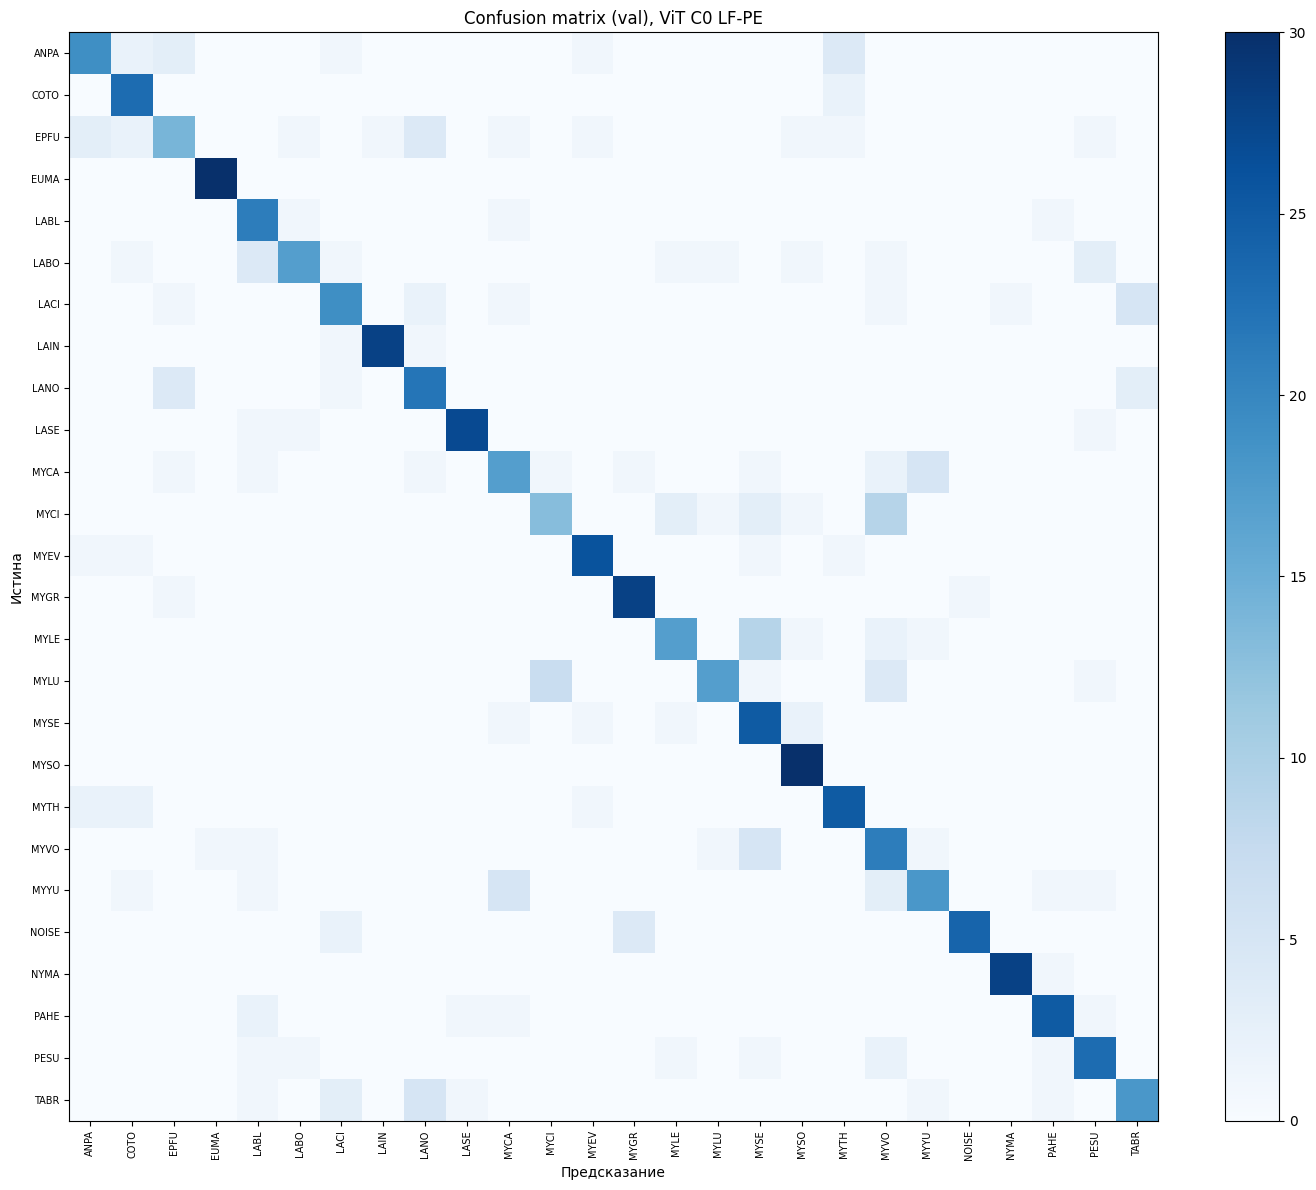

In [11]:
ckpt = torch.load(BEST_CKPT, map_location=device, weights_only=False)

model.load_state_dict(ckpt["model_state"])

val_loss, metrics, y_true, y_pred = evaluate(model)
print("epoch:", ckpt.get("epoch"))
print("macro F1:", metrics["macro_f1"])
print("weighted F1:", metrics["weighted_f1"])
print("weighted precision:", metrics["weighted_prec"])
print("balanced acc:", metrics["bal_acc"])
print("accuracy:", metrics["acc"])
print()
print(classification_report(y_true, y_pred, target_names=species_sorted, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(np.arange(n_classes))
ax.set_yticks(np.arange(n_classes))
ax.set_xticklabels(species_sorted, rotation=90, fontsize=7)
ax.set_yticklabels(species_sorted, fontsize=7)
ax.set_ylabel("Истина")
ax.set_xlabel("Предсказание")
ax.set_title("Confusion matrix (val), ViT C0 LF-PE")
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()
